In [1]:
print("Hello, World!")

Hello, World!


# 04_2 DQA-CWA v2 Evaluation

This notebook is a read-only analysis pass for the DQA-CWA v2 run. It follows the same evaluation layout as 03_2, but points at the v2 workspace and labels the method as DQA-CWA v2 in comparisons.

In [2]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    required = (
        "dynamic_quality_aware_classwise_aggregation/run_dqa_cwa_fedsto.py",
        "navigating_data_heterogeneity/setup_fedsto_exact_reproduction.py",
    )
    candidate_dirs = []
    for base in (start, *start.parents):
        candidate_dirs.extend(
            [
                base,
                base / "Object_Detection",
                base / "masters_research" / "Object_Detection",
            ]
        )
    for candidate in candidate_dirs:
        if all((candidate / marker).exists() for marker in required):
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the Object_Detection repository root.")


REPO_ROOT = find_repo_root()
DQA_ROOT = REPO_ROOT / "dynamic_quality_aware_classwise_aggregation"
NAV_ROOT = REPO_ROOT / "navigating_data_heterogeneity"
WORK_ROOT = DQA_ROOT / "efficientteacher_dqa_ver2"
STATS_ROOT = DQA_ROOT / "stats_dqa_ver2"
RUNS_ROOT = WORK_ROOT / "runs"
VALIDATION_ROOT = WORK_ROOT / "validation_reports"
NOTEBOOK_GENERATOR = DQA_ROOT / "generate_dqa_cwa_notebook.py"
METHOD_LABEL = "DQA-CWA v2"

FEDSTO_WORK_ROOT = NAV_ROOT / "efficientteacher_fedsto"
FEDSTO_TRAINING_SUMMARY = FEDSTO_WORK_ROOT / "validation_reports" / "tables" / "training_run_summary.csv"
FEDSTO_PAPER_EVAL_SUMMARY = FEDSTO_WORK_ROOT / "validation_reports" / "paper_protocol_eval_summary.csv"

if sns is not None:
    sns.set_theme(style="whitegrid", context="talk")
else:
    plt.style.use("ggplot")
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200


def plot_line(ax, data: pd.DataFrame, *, x: str, y: str, hue: str | None = None, marker: str | None = None, linewidth: float = 2.0):
    if sns is not None:
        return sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker, linewidth=linewidth, ax=ax)

    if hue is not None and hue in data.columns:
        for key, frame in data.groupby(hue):
            ordered = frame.sort_values(x)
            ax.plot(ordered[x], ordered[y], marker=marker, linewidth=linewidth, label=str(key))
        ax.legend(title=hue)
    else:
        ordered = data.sort_values(x)
        ax.plot(ordered[x], ordered[y], marker=marker, linewidth=linewidth)
    return ax


def plot_bar(ax, data: pd.DataFrame, *, x: str, y: str, hue: str | None = None):
    if sns is not None:
        return sns.barplot(data=data, x=x, y=y, hue=hue, ax=ax)

    if hue is not None and hue in data.columns:
        pivot = data.pivot_table(index=x, columns=hue, values=y, aggfunc="mean")
        pivot.plot(kind="bar", ax=ax)
    else:
        grouped = data.groupby(x, as_index=False)[y].mean()
        ax.bar(grouped[x], grouped[y])
    return ax


def plot_heatmap(
    ax,
    matrix,
    *,
    row_labels: list[str],
    col_labels: list[str],
    title: str,
    cmap: str = "viridis",
    fmt: str = ".2f",
    annotate: bool = True,
    vmin: float | None = None,
    vmax: float | None = None,
):
    values = np.asarray(matrix, dtype=float)
    if sns is not None:
        sns.heatmap(
            values,
            ax=ax,
            cmap=cmap,
            annot=annotate,
            fmt=fmt,
            xticklabels=col_labels,
            yticklabels=row_labels,
            vmin=vmin,
            vmax=vmax,
        )
    else:
        image = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels(col_labels, rotation=45, ha="right")
        ax.set_yticks(range(len(row_labels)))
        ax.set_yticklabels(row_labels)
        if annotate:
            for row_idx in range(values.shape[0]):
                for col_idx in range(values.shape[1]):
                    ax.text(
                        col_idx,
                        row_idx,
                        format(values[row_idx, col_idx], fmt),
                        ha="center",
                        va="center",
                        color="white" if values[row_idx, col_idx] > np.nanmean(values) else "black",
                        fontsize=9,
                    )
    ax.set_title(title)
    ax.set_xlabel("class")
    ax.set_ylabel("")
    return ax

print("repo_root:", REPO_ROOT)
print("workspace:", WORK_ROOT)
print("runs_root:", RUNS_ROOT)
print("validation_root:", VALIDATION_ROOT)

repo_root: /app/Object_Detection
workspace: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2
runs_root: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2/runs
validation_root: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2/validation_reports


## 1. Workspace and Artifact Status

Start with a compact snapshot of what exists: manifest, history, checkpoints, stats, and partial or complete paper-eval outputs.

In [3]:
def modified_utc(path: Path) -> str:
    if not path.exists():
        return ""
    return datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat()


manifest_path = WORK_ROOT / "manifest.json"
history_path = WORK_ROOT / "history.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
history = json.loads(history_path.read_text(encoding="utf-8")) if history_path.exists() else []

artifact_rows = [
    {"artifact": "workspace", "path": str(WORK_ROOT), "exists": WORK_ROOT.exists(), "modified_utc": modified_utc(WORK_ROOT)},
    {"artifact": "stats_root", "path": str(STATS_ROOT), "exists": STATS_ROOT.exists(), "modified_utc": modified_utc(STATS_ROOT)},
    {"artifact": "manifest", "path": str(manifest_path), "exists": manifest_path.exists(), "modified_utc": modified_utc(manifest_path)},
    {"artifact": "history", "path": str(history_path), "exists": history_path.exists(), "modified_utc": modified_utc(history_path)},
    {"artifact": "global_checkpoints", "path": str(WORK_ROOT / "global_checkpoints"), "exists": (WORK_ROOT / "global_checkpoints").exists(), "modified_utc": modified_utc(WORK_ROOT / "global_checkpoints")},
    {"artifact": "paper_eval_summary_csv", "path": str(VALIDATION_ROOT / "paper_protocol_eval_summary.csv"), "exists": (VALIDATION_ROOT / "paper_protocol_eval_summary.csv").exists(), "modified_utc": modified_utc(VALIDATION_ROOT / "paper_protocol_eval_summary.csv")},
    {"artifact": "paper_eval_manifest_json", "path": str(VALIDATION_ROOT / "paper_protocol_eval_manifest.json"), "exists": (VALIDATION_ROOT / "paper_protocol_eval_manifest.json").exists(), "modified_utc": modified_utc(VALIDATION_ROOT / "paper_protocol_eval_manifest.json")},
]
display(pd.DataFrame(artifact_rows))

completed_phase1 = sum(1 for entry in history if int(entry.get("phase", 0)) == 1)
completed_phase2 = sum(1 for entry in history if int(entry.get("phase", 0)) == 2)
progress_rows = [
    {"phase": "phase1", "completed_rounds": completed_phase1},
    {"phase": "phase2", "completed_rounds": completed_phase2},
    {"phase": "total", "completed_rounds": len(history)},
]
display(pd.DataFrame(progress_rows))

manifest_summary = {
    "classes": manifest.get("classes", []),
    "server_weather": manifest.get("server", {}).get("weather"),
    "server_train_images": manifest.get("server", {}).get("train_images"),
    "server_val_images": manifest.get("server", {}).get("val_images"),
    "client_weathers": [client.get("weather") for client in manifest.get("clients", [])],
    "run_dirs": len(list(RUNS_ROOT.glob("*"))),
    "results_csv_files": len(list(RUNS_ROOT.glob("*/results.csv"))),
    "phase1_stats_files": len(list(STATS_ROOT.glob("phase1_round*.json"))),
    "phase2_stats_files": len(list(STATS_ROOT.glob("phase2_round*.json"))),
    "paper_eval_logs": len(list((VALIDATION_ROOT / "paper_protocol_logs").glob("*.log"))),
    "paper_eval_run_dirs": len(list((VALIDATION_ROOT / "paper_protocol_val_runs").glob("*"))),
}
manifest_summary

,artifact,path,exists,modified_utc
0,workspace,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T14:17:01.440562+00:00
1,stats_root,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:05:53.239378+00:00
2,manifest,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T11:14:36.192856+00:00
3,history,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:08:36.962626+00:00
4,global_checkpoints,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:08:36.972626+00:00
5,paper_eval_summary_csv,/app/Object_Detection/dynamic_quality_aware_cl...,False,
6,paper_eval_manifest_json,/app/Object_Detection/dynamic_quality_aware_cl...,False,


,phase,completed_rounds
0,phase1,14
1,phase2,27
2,total,41


{'classes': ['person',
  'rider',
  'car',
  'bus',
  'truck',
  'bike',
  'motor',
  'traffic light',
  'traffic sign',
  'train'],
 'server_weather': "cloudy represented by BDD100K Kaggle weather='partly cloudy'",
 'server_train_images': 4881,
 'server_val_images': 738,
 'client_weathers': ['overcast', 'rainy', 'snowy'],
 'run_dirs': 165,
 'results_csv_files': 165,
 'phase1_stats_files': 0,
 'phase2_stats_files': 108,
 'paper_eval_logs': 0,
 'paper_eval_run_dirs': 0}

## 2. Build a Compact Training Summary

Parse every `runs/*/results.csv`, normalize it into one table, and save a reusable `training_run_summary.csv` under `validation_reports/tables/`.

In [4]:
def normalize_results_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = df.rename(columns=lambda col: col.strip())
    return renamed


def parse_run_name(run_name: str) -> dict | None:
    if run_name == "runtime_server_warmup":
        return {
            "phase": 0,
            "round": 0,
            "role": "warmup",
            "client_id": np.nan,
            "weather": "server_cloudy",
        }

    match = re.fullmatch(
        r"dqa_phase(?P<phase>[12])_round(?P<round>\d{3})_(?:(?P<server>server)|client(?P<client_id>\d+)_(?P<weather>[a-z]+))",
        run_name,
    )
    if not match:
        return None

    phase = int(match.group("phase"))
    round_idx = int(match.group("round"))
    if match.group("server"):
        return {
            "phase": phase,
            "round": round_idx,
            "role": "server",
            "client_id": np.nan,
            "weather": "server_cloudy",
        }
    return {
        "phase": phase,
        "round": round_idx,
        "role": "client",
        "client_id": int(match.group("client_id")),
        "weather": match.group("weather"),
    }


def safe_float(value) -> float:
    if pd.isna(value):
        return np.nan
    return float(value)


metric_columns = {
    "precision": "metrics/precision",
    "recall": "metrics/recall",
    "mAP_0.5": "metrics/mAP_0.5",
    "mAP_0.5:0.95": "metrics/mAP_0.5:0.95",
}
train_loss_columns = {
    "box_loss": "train/box_loss",
    "obj_loss": "train/obj_loss",
    "cls_loss": "train/cls_loss",
}
val_loss_columns = {
    "box_loss": "val/box_loss",
    "obj_loss": "val/obj_loss",
    "cls_loss": "val/cls_loss",
}


summary_rows = []
best_basis = "metrics/mAP_0.5:0.95"
for results_path in sorted(RUNS_ROOT.glob("*/results.csv")):
    run_name = results_path.parent.name
    meta = parse_run_name(run_name)
    if meta is None:
        continue

    df = normalize_results_columns(pd.read_csv(results_path))
    best_idx = df[best_basis].astype(float).idxmax()
    final_row = df.iloc[-1]
    best_row = df.loc[best_idx]

    row = {
        "run_name": run_name,
        "run_dir": str(results_path.parent),
        "phase": meta["phase"],
        "round": meta["round"],
        "role": meta["role"],
        "client_id": meta["client_id"],
        "weather": meta["weather"],
        "n_logged_rows": len(df),
        "final_epoch": int(final_row["epoch"]),
        "best_epoch": int(best_row["epoch"]),
        "best_basis": best_basis,
    }

    for prefix, source_row in (("final", final_row), ("best", best_row)):
        for metric_name, column_name in metric_columns.items():
            row[f"{prefix}_metrics/{metric_name}"] = safe_float(source_row[column_name])
        for loss_name, column_name in train_loss_columns.items():
            row[f"{prefix}_train/{loss_name}"] = safe_float(source_row[column_name])
        for loss_name, column_name in val_loss_columns.items():
            row[f"{prefix}_val/{loss_name}"] = safe_float(source_row[column_name])

    summary_rows.append(row)

run_summary = pd.DataFrame(summary_rows)
if run_summary.empty:
    raise RuntimeError(f"No DQA results.csv files were found under {RUNS_ROOT}")

run_summary["client_id_sort"] = run_summary["client_id"].fillna(-1)
run_summary = (
    run_summary
    .sort_values(["phase", "round", "role", "client_id_sort"])
    .drop(columns=["client_id_sort"])
    .reset_index(drop=True)
)

validation_table_root = VALIDATION_ROOT / "tables"
validation_table_root.mkdir(parents=True, exist_ok=True)
training_summary_path = validation_table_root / "training_run_summary.csv"
run_summary.to_csv(training_summary_path, index=False)

server_summary = run_summary[run_summary["role"].isin(["warmup", "server"])].copy()
client_summary = run_summary[run_summary["role"] == "client"].copy()

print("Wrote training summary:", training_summary_path)
display(run_summary.groupby(["phase", "role"], dropna=False).size().reset_index(name="runs"))
display(run_summary.head(12))

Wrote training summary: /app/Object_Detection/dynamic_quality_aware_classwise_aggregation/efficientteacher_dqa_ver2/validation_reports/tables/training_run_summary.csv


,phase,role,runs
0,0,warmup,1
1,1,client,42
2,1,server,14
3,2,client,81
4,2,server,27


,run_name,run_dir,phase,round,role,client_id,weather,n_logged_rows,final_epoch,best_epoch,best_basis,final_metrics/precision,final_metrics/recall,final_metrics/mAP_0.5,final_metrics/mAP_0.5:0.95,final_train/box_loss,final_train/obj_loss,final_train/cls_loss,final_val/box_loss,final_val/obj_loss,final_val/cls_loss,best_metrics/precision,best_metrics/recall,best_metrics/mAP_0.5,best_metrics/mAP_0.5:0.95,best_train/box_loss,best_train/obj_loss,best_train/cls_loss,best_val/box_loss,best_val/obj_loss,best_val/cls_loss
0,runtime_server_warmup,/app/Object_Detection/dynamic_quality_aware_cl...,0,0,warmup,NaN,server_cloudy,15,14,14,metrics/mAP_0.5:0.95,0.582560,0.405960,0.423320,0.232330,0.042333,0.043637,0.006028,0.0,0.0,0.0,0.582560,0.405960,0.423320,0.232330,0.042333,0.043637,0.006028,0.0,0.0,0.0
1,dqa_phase1_round001_client0_overcast,/app/Object_Detection/dynamic_quality_aware_cl...,1,1,client,0.0,overcast,1,0,0,metrics/mAP_0.5:0.95,0.406530,0.186760,0.167710,0.093647,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.406530,0.186760,0.167710,0.093647,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,dqa_phase1_round001_client1_rainy,/app/Object_Detection/dynamic_quality_aware_cl...,1,1,client,1.0,rainy,1,0,0,metrics/mAP_0.5:0.95,0.089527,0.041311,0.060006,0.034494,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.089527,0.041311,0.060006,0.034494,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,dqa_phase1_round001_client2_snowy,/app/Object_Detection/dynamic_quality_aware_cl...,1,1,client,2.0,snowy,1,0,0,metrics/mAP_0.5:0.95,0.233030,0.093530,0.094450,0.047615,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.233030,0.093530,0.094450,0.047615,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,dqa_phase1_round001_server,/app/Object_Detection/dynamic_quality_aware_cl...,1,1,server,NaN,server_cloudy,1,0,0,metrics/mAP_0.5:0.95,0.587490,0.410600,0.417670,0.237540,0.039384,0.042916,0.005854,0.0,0.0,0.0,0.587490,0.410600,0.417670,0.237540,0.039384,0.042916,0.005854,0.0,0.0,0.0
5,dqa_phase1_round002_client0_overcast,/app/Object_Detection/dynamic_quality_aware_cl...,1,2,client,0.0,overcast,1,0,0,metrics/mAP_0.5:0.95,0.527260,0.319530,0.308480,0.181840,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.527260,0.319530,0.308480,0.181840,0.000000,0.000000,0.000000,0.0,0.0,0.0
6,dqa_phase1_round002_client1_rainy,/app/Object_Detection/dynamic_quality_aware_cl...,1,2,client,1.0,rainy,1,0,0,metrics/mAP_0.5:0.95,0.397760,0.122720,0.120440,0.069263,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.397760,0.122720,0.120440,0.069263,0.000000,0.000000,0.000000,0.0,0.0,0.0
7,dqa_phase1_round002_client2_snowy,/app/Object_Detection/dynamic_quality_aware_cl...,1,2,client,2.0,snowy,1,0,0,metrics/mAP_0.5:0.95,0.369430,0.126260,0.123610,0.073407,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.369430,0.126260,0.123610,0.073407,0.000000,0.000000,0.000000,0.0,0.0,0.0
8,dqa_phase1_round002_server,/app/Object_Detection/dynamic_quality_aware_cl...,1,2,server,NaN,server_cloudy,1,0,0,metrics/mAP_0.5:0.95,0.576990,0.434910,0.432880,0.244560,0.037450,0.039604,0.005069,0.0,0.0,0.0,0.576990,0.434910,0.432880,0.244560,0.037450,0.039604,0.005069,0.0,0.0,0.0
9,dqa_phase1_round003_client0_overcast,/app/Object_Detection/dynamic_quality_aware_cl...,1,3,client,0.0,overcast,1,0,0,metrics/mAP_0.5:0.95,0.118580,0.018405,0.067459,0.041680,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.118580,0.018405,0.067459,0.041680,0.000000,0.000000,0.000000,0.0,0.0,0.0


## 3. Key DQA Checkpoints

Pull out the warm-up baseline, the best phase-1 server round, the best phase-2 server round, and the final phase-2 server round. Then show the latest client snapshot by weather.

In [5]:
def labeled_checkpoint_rows(summary: pd.DataFrame) -> pd.DataFrame:
    selections = []
    candidates = [
        ("warmup", summary[summary["phase"] == 0], "best"),
        ("best_phase1_server", summary[(summary["phase"] == 1) & (summary["role"] == "server")], "best"),
        ("best_phase2_server", summary[(summary["phase"] == 2) & (summary["role"] == "server")], "best"),
        ("final_phase2_server", summary[(summary["phase"] == 2) & (summary["role"] == "server")], "final"),
    ]

    for label, frame, source in candidates:
        if frame.empty:
            continue
        if source == "final":
            chosen = frame.sort_values(["round", "best_epoch"]).iloc[-1].copy()
        else:
            chosen = frame.sort_values("best_metrics/mAP_0.5:0.95", ascending=False).iloc[0].copy()
        chosen["checkpoint"] = label
        chosen["metric_source"] = source
        selections.append(chosen)

    if not selections:
        return pd.DataFrame()
    return pd.DataFrame(selections)


key_server = labeled_checkpoint_rows(server_summary)
if not key_server.empty:
    warmup_baseline = key_server.loc[key_server["checkpoint"] == "warmup", "best_metrics/mAP_0.5:0.95"]
    baseline = warmup_baseline.iloc[0] if not warmup_baseline.empty else np.nan
    key_server["delta_vs_warmup_mAP_0.5:0.95"] = key_server["best_metrics/mAP_0.5:0.95"] - baseline
    display(
        key_server[
            [
                "checkpoint",
                "run_name",
                "phase",
                "round",
                "metric_source",
                "final_metrics/precision",
                "final_metrics/recall",
                "final_metrics/mAP_0.5",
                "final_metrics/mAP_0.5:0.95",
                "best_metrics/mAP_0.5",
                "best_metrics/mAP_0.5:0.95",
                "delta_vs_warmup_mAP_0.5:0.95",
            ]
        ].round(4)
    )

latest_clients = (
    client_summary
    .sort_values(["phase", "round"])
    .groupby(["phase", "weather"], as_index=False)
    .tail(1)
    .sort_values(["phase", "weather"])
)
display(
    latest_clients[
        [
            "phase",
            "weather",
            "round",
            "final_metrics/precision",
            "final_metrics/recall",
            "final_metrics/mAP_0.5",
            "final_metrics/mAP_0.5:0.95",
        ]
    ].round(4)
)

,checkpoint,run_name,phase,round,metric_source,final_metrics/precision,final_metrics/recall,final_metrics/mAP_0.5,final_metrics/mAP_0.5:0.95,best_metrics/mAP_0.5,best_metrics/mAP_0.5:0.95,delta_vs_warmup_mAP_0.5:0.95
0,warmup,runtime_server_warmup,0,0,best,0.5826,0.4060,0.4233,0.2323,0.4233,0.2323,0.0000
8,best_phase1_server,dqa_phase1_round002_server,1,2,best,0.5770,0.4349,0.4329,0.2446,0.4329,0.2446,0.0122
104,best_phase2_server,dqa_phase2_round012_server,2,12,best,0.6960,0.3553,0.3984,0.2149,0.3984,0.2149,-0.0174
164,final_phase2_server,dqa_phase2_round027_server,2,27,final,0.6821,0.3507,0.3791,0.2092,0.3791,0.2092,-0.0231


,phase,weather,round,final_metrics/precision,final_metrics/recall,final_metrics/mAP_0.5,final_metrics/mAP_0.5:0.95
53,1,overcast,14,0.0844,0.0411,0.0587,0.0362
54,1,rainy,14,0.1018,0.0197,0.0582,0.0393
55,1,snowy,14,0.2248,0.1956,0.1616,0.0883
161,2,overcast,27,0.0024,0.0056,0.0013,0.0004
162,2,rainy,27,0.0000,0.0000,0.0000,0.0000
163,2,snowy,27,0.0000,0.0000,0.0000,0.0000


## 4. Server Metric Curves

Plot the warm-up epochs and the federated server rounds on one stitched timeline so the main mAP, precision, and recall trends are easy to scan.

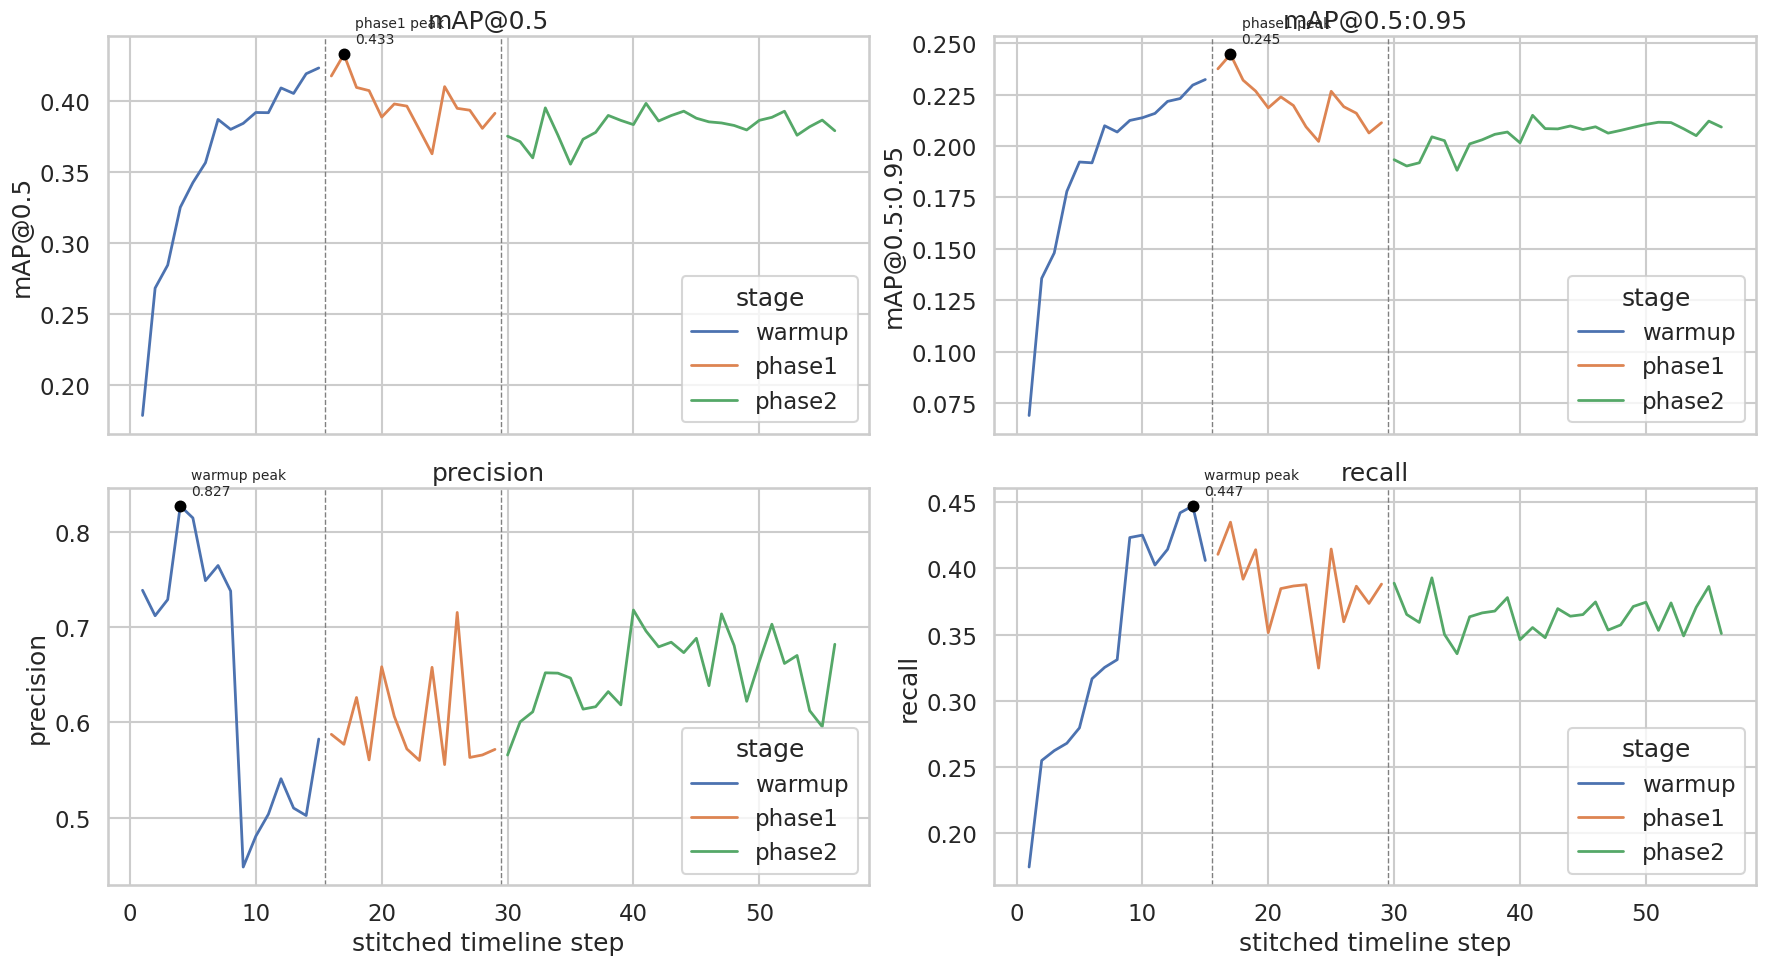

In [6]:
warmup_history_path = RUNS_ROOT / "runtime_server_warmup" / "results.csv"
warmup_history = normalize_results_columns(pd.read_csv(warmup_history_path))
warmup_epochs = len(warmup_history)
phase1_max_round = int(server_summary.loc[server_summary["phase"] == 1, "round"].max()) if (server_summary["phase"] == 1).any() else 0

warmup_curve = warmup_history[
    [
        "epoch",
        "metrics/precision",
        "metrics/recall",
        "metrics/mAP_0.5",
        "metrics/mAP_0.5:0.95",
    ]
].copy()
warmup_curve["timeline"] = warmup_curve["epoch"] + 1
warmup_curve["stage"] = "warmup"

def server_curve_frame(phase: int, stage: str, offset: int) -> pd.DataFrame:
    phase_df = server_summary[(server_summary["phase"] == phase) & (server_summary["role"] == "server")].copy()
    if phase_df.empty:
        return pd.DataFrame(columns=["timeline", "stage", "round", "metrics/precision", "metrics/recall", "metrics/mAP_0.5", "metrics/mAP_0.5:0.95"])
    phase_df["timeline"] = offset + phase_df["round"]
    phase_df["stage"] = stage
    phase_df = phase_df.rename(
        columns={
            "final_metrics/precision": "metrics/precision",
            "final_metrics/recall": "metrics/recall",
            "final_metrics/mAP_0.5": "metrics/mAP_0.5",
            "final_metrics/mAP_0.5:0.95": "metrics/mAP_0.5:0.95",
        }
    )
    return phase_df[
        [
            "timeline",
            "stage",
            "round",
            "metrics/precision",
            "metrics/recall",
            "metrics/mAP_0.5",
            "metrics/mAP_0.5:0.95",
        ]
    ]


curve_df = pd.concat(
    [
        warmup_curve[["timeline", "stage", "metrics/precision", "metrics/recall", "metrics/mAP_0.5", "metrics/mAP_0.5:0.95"]],
        server_curve_frame(1, "phase1", warmup_epochs),
        server_curve_frame(2, "phase2", warmup_epochs + phase1_max_round),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
metric_specs = [
    ("metrics/mAP_0.5", "mAP@0.5"),
    ("metrics/mAP_0.5:0.95", "mAP@0.5:0.95"),
    ("metrics/precision", "precision"),
    ("metrics/recall", "recall"),
]

for ax, (metric_col, title) in zip(axes.flat, metric_specs):
    plot_line(ax, curve_df, x="timeline", y=metric_col, hue="stage", linewidth=2)
    if warmup_epochs:
        ax.axvline(warmup_epochs + 0.5, color="gray", linestyle="--", linewidth=1)
    if phase1_max_round:
        ax.axvline(warmup_epochs + phase1_max_round + 0.5, color="gray", linestyle="--", linewidth=1)
    best_idx = curve_df[metric_col].idxmax()
    best_row = curve_df.loc[best_idx]
    ax.scatter([best_row["timeline"]], [best_row[metric_col]], color="black", s=50, zorder=5)
    ax.annotate(
        f"{best_row['stage']} peak\n{best_row[metric_col]:.3f}",
        (best_row["timeline"], best_row[metric_col]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=10,
    )
    ax.set_title(title)
    ax.set_xlabel("stitched timeline step")
    ax.set_ylabel(title)

plt.tight_layout()
plt.show()

## 5. Plateau and Loss Diagnostics

These views are meant to answer the practical question quickly: is phase 2 still improving, or has it already flattened into pseudo-label noise?

,phase,round,final_metrics/mAP_0.5,final_metrics/mAP_0.5:0.95,cummax_map50,cummax_map50_95,delta_prev_map50,delta_prev_map50_95,delta_vs_warmup_map50,delta_vs_warmup_map50_95
31,2,18,0.3846,0.2063,0.3984,0.2149,-0.0008,-0.0031,-0.0388,-0.0261
32,2,19,0.3828,0.2076,0.3984,0.2149,-0.0018,0.0013,-0.0405,-0.0247
33,2,20,0.3796,0.2091,0.3984,0.2149,-0.0032,0.0015,-0.0437,-0.0233
34,2,21,0.3864,0.2105,0.3984,0.2149,0.0068,0.0014,-0.0369,-0.0218
35,2,22,0.3885,0.2116,0.3984,0.2149,0.0021,0.0011,-0.0348,-0.0208
36,2,23,0.3928,0.2114,0.3984,0.2149,0.0043,-0.0002,-0.0305,-0.0209
37,2,24,0.3759,0.2084,0.3984,0.2149,-0.0169,-0.0030,-0.0474,-0.0240
38,2,25,0.3819,0.2050,0.3984,0.2149,0.0060,-0.0033,-0.0414,-0.0273
39,2,26,0.3866,0.2121,0.3984,0.2149,0.0047,0.0071,-0.0367,-0.0202
40,2,27,0.3791,0.2092,0.3984,0.2149,-0.0075,-0.0029,-0.0442,-0.0231


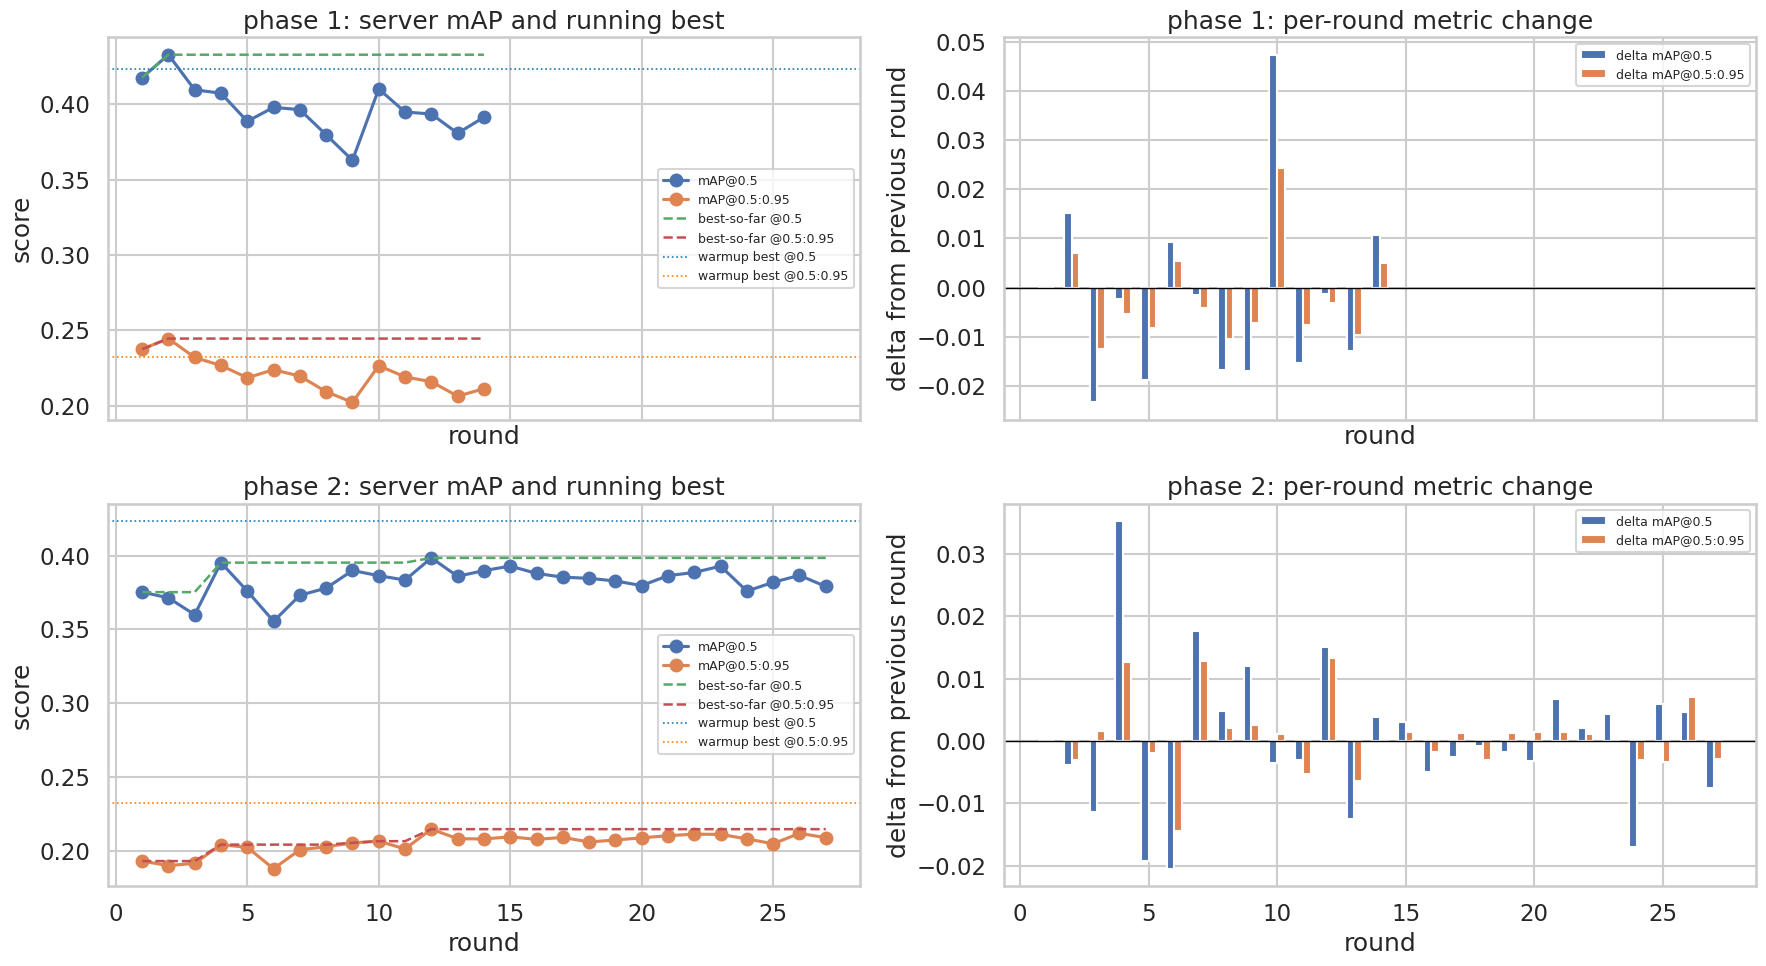

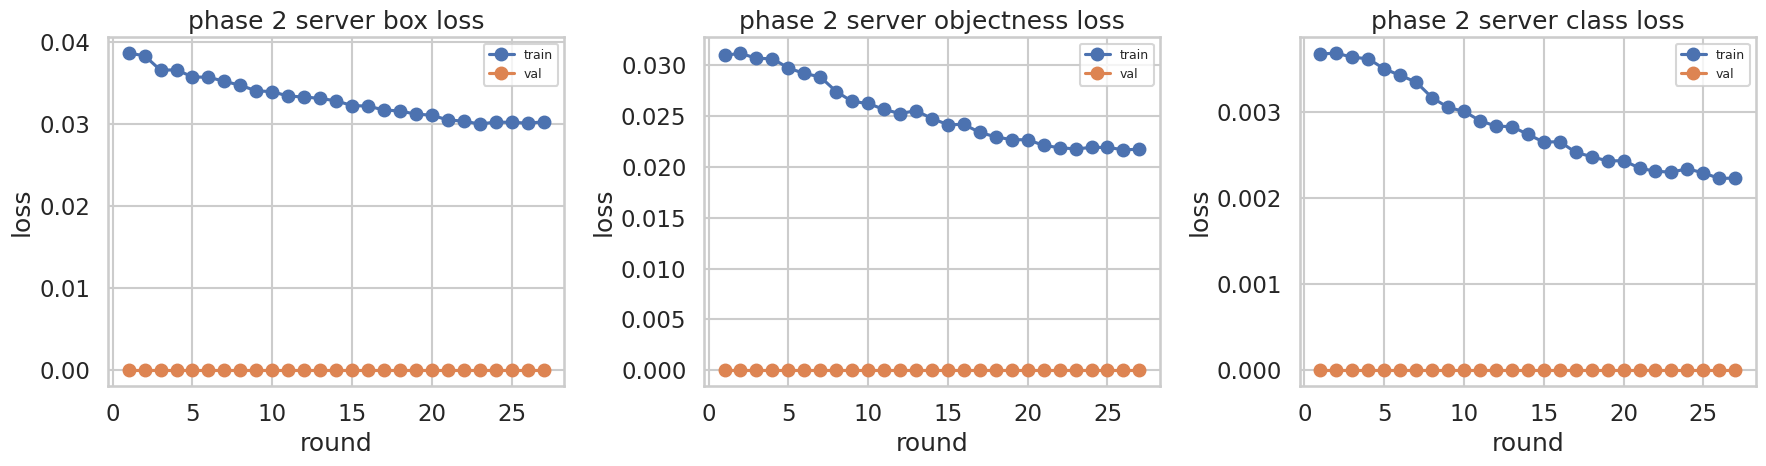

In [7]:
warmup_map50 = float(warmup_curve["metrics/mAP_0.5"].max())
warmup_map50_95 = float(warmup_curve["metrics/mAP_0.5:0.95"].max())

phase_detail_frames = []
for phase in [1, 2]:
    phase_df = (
        server_summary[(server_summary["phase"] == phase) & (server_summary["role"] == "server")]
        .sort_values("round")
        .copy()
    )
    if phase_df.empty:
        continue
    phase_df["cummax_map50"] = phase_df["final_metrics/mAP_0.5"].cummax()
    phase_df["cummax_map50_95"] = phase_df["final_metrics/mAP_0.5:0.95"].cummax()
    phase_df["delta_prev_map50"] = phase_df["final_metrics/mAP_0.5"].diff()
    phase_df["delta_prev_map50_95"] = phase_df["final_metrics/mAP_0.5:0.95"].diff()
    phase_df["delta_vs_warmup_map50"] = phase_df["final_metrics/mAP_0.5"] - warmup_map50
    phase_df["delta_vs_warmup_map50_95"] = phase_df["final_metrics/mAP_0.5:0.95"] - warmup_map50_95
    phase_detail_frames.append(phase_df)

phase_detail_df = pd.concat(phase_detail_frames, ignore_index=True) if phase_detail_frames else pd.DataFrame()

if not phase_detail_df.empty:
    display(
        phase_detail_df[
            [
                "phase",
                "round",
                "final_metrics/mAP_0.5",
                "final_metrics/mAP_0.5:0.95",
                "cummax_map50",
                "cummax_map50_95",
                "delta_prev_map50",
                "delta_prev_map50_95",
                "delta_vs_warmup_map50",
                "delta_vs_warmup_map50_95",
            ]
        ].tail(10).round(4)
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex="col")
    for row_idx, phase in enumerate([1, 2]):
        phase_df = phase_detail_df[phase_detail_df["phase"] == phase].copy()
        if phase_df.empty:
            axes[row_idx, 0].set_visible(False)
            axes[row_idx, 1].set_visible(False)
            continue

        ax_curve = axes[row_idx, 0]
        ax_curve.plot(phase_df["round"], phase_df["final_metrics/mAP_0.5"], marker="o", label="mAP@0.5")
        ax_curve.plot(phase_df["round"], phase_df["final_metrics/mAP_0.5:0.95"], marker="o", label="mAP@0.5:0.95")
        ax_curve.plot(phase_df["round"], phase_df["cummax_map50"], linestyle="--", linewidth=1.8, label="best-so-far @0.5")
        ax_curve.plot(phase_df["round"], phase_df["cummax_map50_95"], linestyle="--", linewidth=1.8, label="best-so-far @0.5:0.95")
        ax_curve.axhline(warmup_map50, color="tab:blue", linestyle=":", linewidth=1.2, label="warmup best @0.5")
        ax_curve.axhline(warmup_map50_95, color="tab:orange", linestyle=":", linewidth=1.2, label="warmup best @0.5:0.95")
        ax_curve.set_title(f"phase {phase}: server mAP and running best")
        ax_curve.set_xlabel("round")
        ax_curve.set_ylabel("score")
        ax_curve.legend(fontsize=9)

        ax_delta = axes[row_idx, 1]
        ax_delta.bar(phase_df["round"] - 0.15, phase_df["delta_prev_map50"].fillna(0.0), width=0.3, label="delta mAP@0.5")
        ax_delta.bar(phase_df["round"] + 0.15, phase_df["delta_prev_map50_95"].fillna(0.0), width=0.3, label="delta mAP@0.5:0.95")
        ax_delta.axhline(0.0, color="black", linewidth=1.0)
        ax_delta.set_title(f"phase {phase}: per-round metric change")
        ax_delta.set_xlabel("round")
        ax_delta.set_ylabel("delta from previous round")
        ax_delta.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    phase2_detail = phase_detail_df[phase_detail_df["phase"] == 2].copy()
    if not phase2_detail.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
        loss_specs = [
            ("box", "box loss"),
            ("obj", "objectness loss"),
            ("cls", "class loss"),
        ]
        for ax, (loss_key, title) in zip(axes, loss_specs):
            ax.plot(phase2_detail["round"], phase2_detail[f"final_train/{loss_key}_loss"], marker="o", label="train")
            ax.plot(phase2_detail["round"], phase2_detail[f"final_val/{loss_key}_loss"], marker="o", label="val")
            ax.set_title(f"phase 2 server {title}")
            ax.set_xlabel("round")
            ax.set_ylabel("loss")
            ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

## 6. DQA Guard and Pseudo-Label Diagnostics

These plots connect the DQA-specific internals to the accuracy curve: pseudo-label volume, quality, whether the round guard actually skipped DQA, and how the final class-wise weights were distributed.

,phase,round,total_pseudo_count,mean_quality,mean_confidence,mean_objectness,used_dqa,guard_active_classes
15,2,16,443676.0,0.7164,0.5979,0.6047,True,9
16,2,17,372529.0,0.6463,0.5004,0.5144,True,9
17,2,18,382768.0,0.6569,0.5156,0.5277,True,9
18,2,19,484802.0,0.6802,0.5491,0.5604,True,9
19,2,20,491891.0,0.7161,0.5985,0.6075,True,9
20,2,21,493350.0,0.7001,0.5771,0.6144,True,9
21,2,22,440931.0,0.6837,0.5524,0.5631,True,9
22,2,23,342647.0,0.6415,0.4950,0.5126,True,9
23,2,24,429926.0,0.6472,0.5004,0.5107,True,9
24,2,25,458577.0,0.7342,0.6236,0.6319,True,9


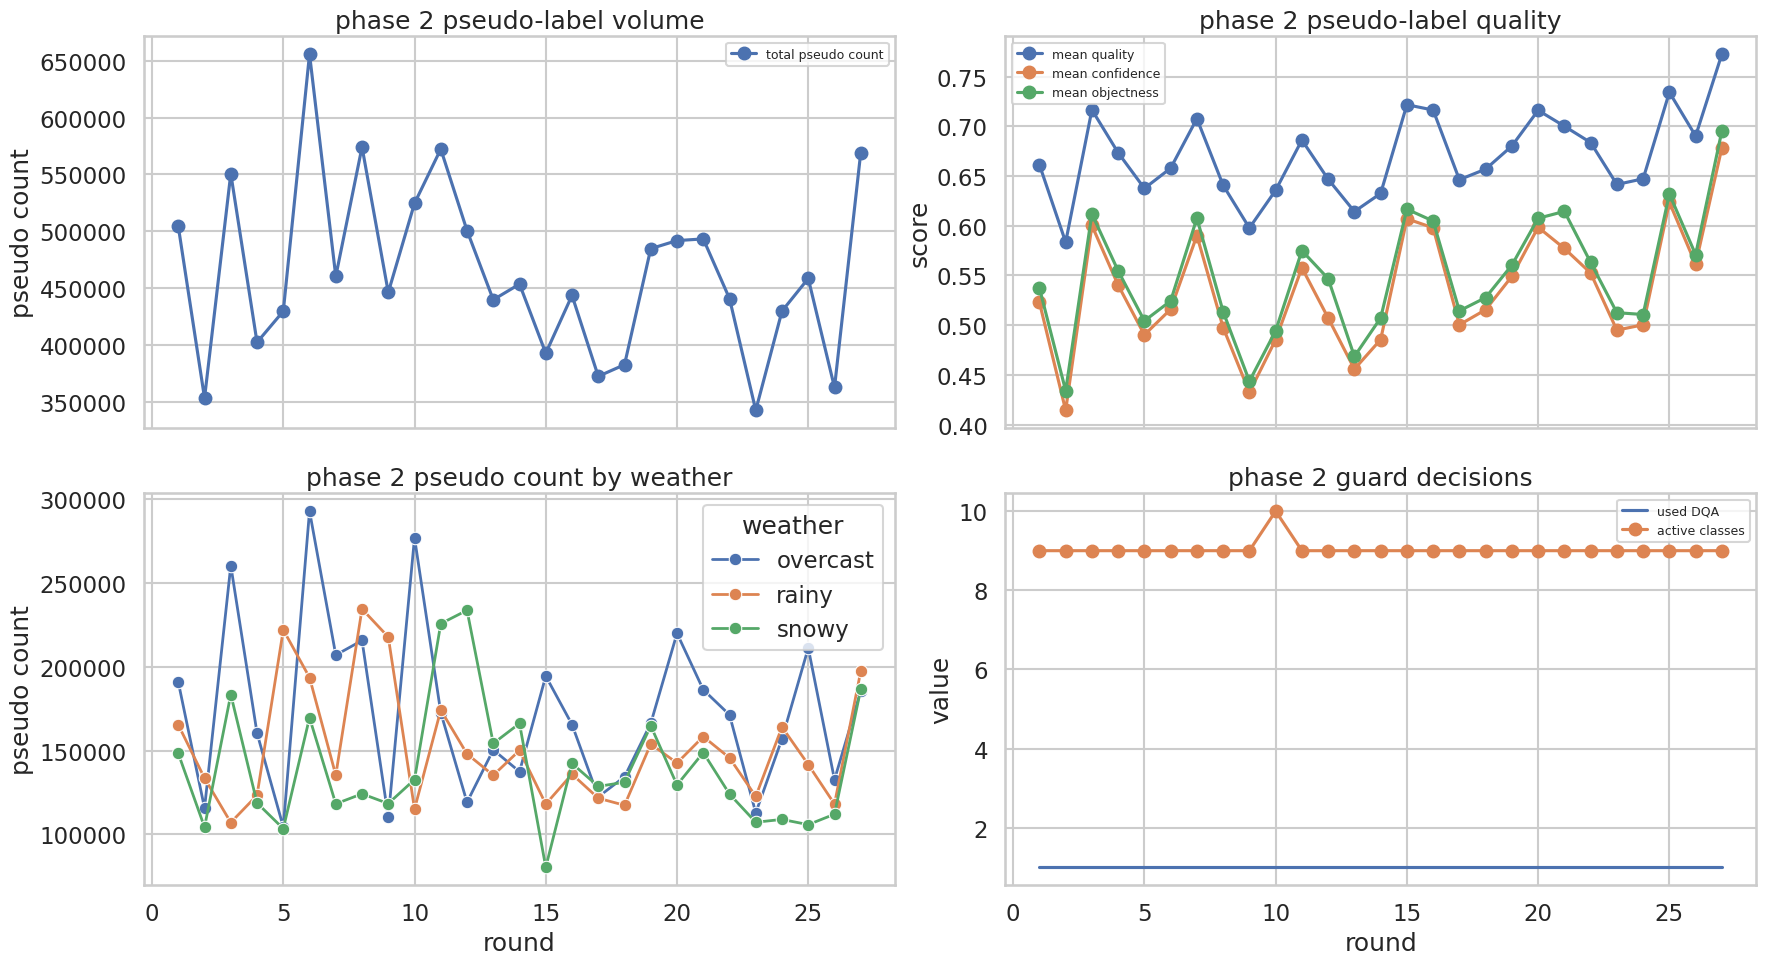

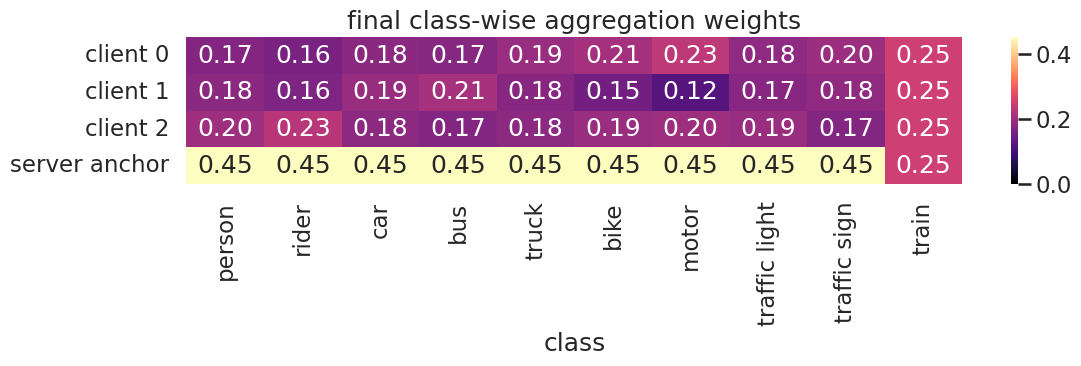

,person,rider,car,bus,truck,bike,motor,traffic light,traffic sign,train
client 0,0.172,0.160,0.178,0.173,0.195,0.207,0.232,0.182,0.196,0.25
client 1,0.178,0.165,0.193,0.208,0.175,0.150,0.118,0.175,0.185,0.25
client 2,0.200,0.226,0.179,0.169,0.180,0.194,0.200,0.194,0.170,0.25
server anchor,0.450,0.450,0.450,0.450,0.450,0.450,0.450,0.450,0.450,0.25


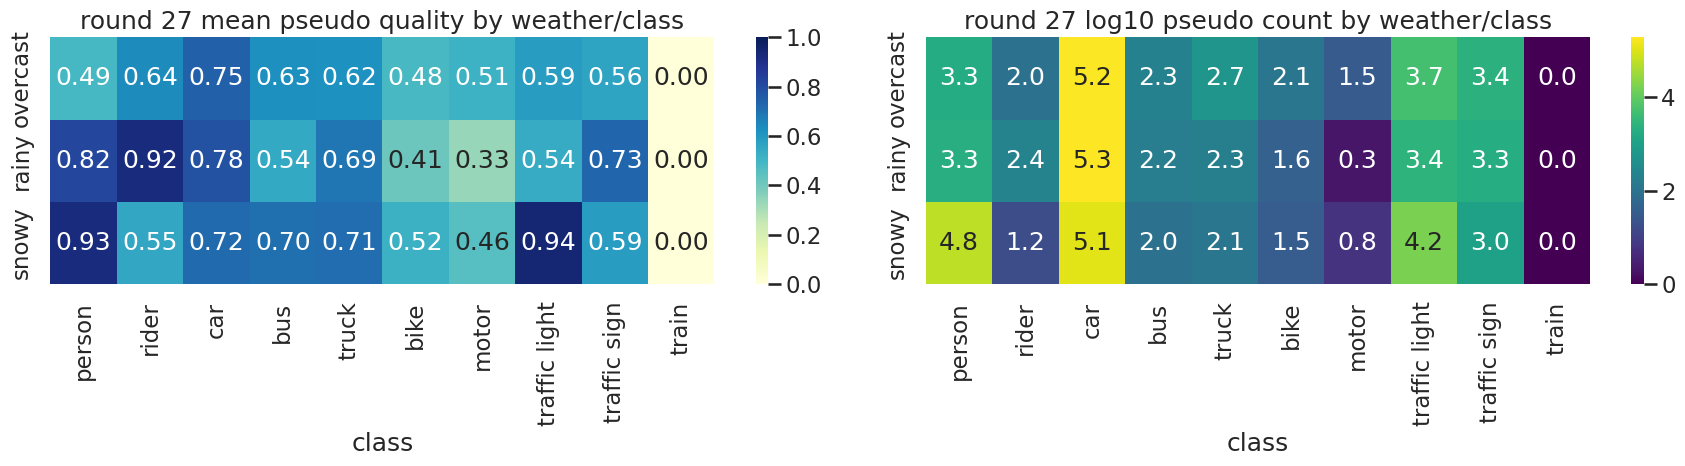

In [8]:
dqa_state_path = WORK_ROOT / "dqa_cwa_state.json"
client_weather_map = {str(client.get("id")): client.get("weather", f"client{client.get('id')}") for client in manifest.get("clients", [])}
class_names = manifest.get("classes", [str(i) for i in range(10)])

def is_round_stats_file(path: Path) -> bool:
    return bool(re.fullmatch(r"phase\d+_round\d+\.json", path.name))


def weighted_average(sum_value: float, total_count: float) -> float:
    return float(sum_value) / float(total_count) if total_count > 0 else 0.0


round_rows = []
weather_rows = []
latest_round_clients = []
round_stats_paths = sorted(path for path in STATS_ROOT.glob("phase*_round*.json") if is_round_stats_file(path))
latest_round_number = -1

for path in round_stats_paths:
    match = re.fullmatch(r"phase(?P<phase>\d+)_round(?P<round>\d+)\.json", path.name)
    if not match:
        continue
    phase = int(match.group("phase"))
    round_idx = int(match.group("round"))
    data = json.loads(path.read_text(encoding="utf-8"))
    clients = data.get("clients", [])

    total_count = 0.0
    quality_sum = 0.0
    confidence_sum = 0.0
    objectness_sum = 0.0
    phase_active_classes = 0
    final_clients_snapshot = []

    for client in clients:
        counts = [float(x) for x in client.get("counts", [])]
        qualities = [float(x) for x in client.get("mean_quality_scores", [])]
        confidences = [float(x) for x in client.get("mean_confidences", [])]
        objectness = [float(x) for x in client.get("mean_objectness", [])]
        client_id = str(client.get("id", client.get("client_id", "?")))
        weather = client_weather_map.get(client_id, f"client{client_id}")
        client_total = float(sum(counts))

        total_count += client_total
        quality_sum += sum(count * quality for count, quality in zip(counts, qualities))
        confidence_sum += sum(count * confidence for count, confidence in zip(counts, confidences))
        objectness_sum += sum(count * obj for count, obj in zip(counts, objectness))
        phase_active_classes = max(phase_active_classes, sum(1 for count in counts if count > 0))

        weather_rows.append(
            {
                "phase": phase,
                "round": round_idx,
                "client_id": client_id,
                "weather": weather,
                "pseudo_count": client_total,
                "mean_quality": weighted_average(sum(count * quality for count, quality in zip(counts, qualities)), client_total),
                "mean_confidence": weighted_average(sum(count * confidence for count, confidence in zip(counts, confidences)), client_total),
                "mean_objectness": weighted_average(sum(count * obj for count, obj in zip(counts, objectness)), client_total),
            }
        )
        final_clients_snapshot.append({"weather": weather, "counts": counts, "qualities": qualities})

    round_rows.append(
        {
            "phase": phase,
            "round": round_idx,
            "total_pseudo_count": total_count,
            "mean_quality": weighted_average(quality_sum, total_count),
            "mean_confidence": weighted_average(confidence_sum, total_count),
            "mean_objectness": weighted_average(objectness_sum, total_count),
            "active_classes_from_stats": phase_active_classes,
        }
    )

    if phase == 2 and round_idx >= latest_round_number:
        latest_round_number = round_idx
        latest_round_clients = final_clients_snapshot

dqa_round_df = pd.DataFrame(round_rows).sort_values(["phase", "round"])
dqa_weather_df = pd.DataFrame(weather_rows).sort_values(["phase", "round", "weather"])

if dqa_state_path.exists():
    state = json.loads(dqa_state_path.read_text(encoding="utf-8"))
    guard_history = pd.DataFrame(state.get("round_guard", {}).get("history", []))
    if not guard_history.empty:
        guard_history = guard_history.rename(columns={"active_classes": "guard_active_classes"})
        dqa_round_df = dqa_round_df.merge(
            guard_history[["phase", "round", "used_dqa", "reason", "total_count", "mean_quality", "guard_active_classes"]],
            on=["phase", "round"],
            how="left",
            suffixes=("", "_guard"),
        )
    last_sources = state.get("last_sources", [])
    last_alpha = state.get("last_alpha", [])
else:
    state = {}
    last_sources = []
    last_alpha = []

if not dqa_round_df.empty:
    display(
        dqa_round_df[
            [
                "phase",
                "round",
                "total_pseudo_count",
                "mean_quality",
                "mean_confidence",
                "mean_objectness",
                "used_dqa",
                "guard_active_classes",
            ]
        ].tail(12).round(4)
    )

    phase2_round_df = dqa_round_df[dqa_round_df["phase"] == 2].copy()
    if not phase2_round_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

        ax = axes[0, 0]
        ax.plot(phase2_round_df["round"], phase2_round_df["total_pseudo_count"], marker="o", label="total pseudo count")
        ax.set_title("phase 2 pseudo-label volume")
        ax.set_ylabel("pseudo count")
        ax.legend(fontsize=9)

        ax = axes[0, 1]
        ax.plot(phase2_round_df["round"], phase2_round_df["mean_quality"], marker="o", label="mean quality")
        ax.plot(phase2_round_df["round"], phase2_round_df["mean_confidence"], marker="o", label="mean confidence")
        ax.plot(phase2_round_df["round"], phase2_round_df["mean_objectness"], marker="o", label="mean objectness")
        ax.set_title("phase 2 pseudo-label quality")
        ax.set_ylabel("score")
        ax.legend(fontsize=9)

        ax = axes[1, 0]
        if not dqa_weather_df.empty:
            phase2_weather = dqa_weather_df[dqa_weather_df["phase"] == 2].copy()
            plot_line(
                ax,
                phase2_weather,
                x="round",
                y="pseudo_count",
                hue="weather",
                marker="o",
            )
        ax.set_title("phase 2 pseudo count by weather")
        ax.set_xlabel("round")
        ax.set_ylabel("pseudo count")

        ax = axes[1, 1]
        if "used_dqa" in phase2_round_df.columns:
            ax.step(
                phase2_round_df["round"],
                phase2_round_df["used_dqa"].fillna(False).astype(int),
                where="mid",
                label="used DQA",
            )
        if "guard_active_classes" in phase2_round_df.columns:
            ax.plot(
                phase2_round_df["round"],
                phase2_round_df["guard_active_classes"].fillna(0),
                marker="o",
                label="active classes",
            )
        ax.set_title("phase 2 guard decisions")
        ax.set_xlabel("round")
        ax.set_ylabel("value")
        ax.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

if last_sources and last_alpha:
    alpha_columns = class_names[: len(last_alpha[0])]
    alpha_index = [source.replace("client:", "client ").replace("server", "server anchor") for source in last_sources]
    alpha_df = pd.DataFrame(last_alpha, index=alpha_index, columns=alpha_columns)
    plt.figure(figsize=(12, 4))
    plot_heatmap(
        plt.gca(),
        alpha_df.values,
        row_labels=list(alpha_df.index),
        col_labels=list(alpha_df.columns),
        title="final class-wise aggregation weights",
        cmap="magma",
        fmt=".2f",
        vmin=0.0,
        vmax=max(float(np.nanmax(alpha_df.values)), 0.35),
    )
    plt.tight_layout()
    plt.show()
    display(alpha_df.round(3))

if latest_round_clients:
    final_quality_df = pd.DataFrame(
        [client["qualities"] for client in latest_round_clients],
        index=[client["weather"] for client in latest_round_clients],
        columns=class_names[: len(latest_round_clients[0]["qualities"])],
    )
    final_count_df = pd.DataFrame(
        [client["counts"] for client in latest_round_clients],
        index=[client["weather"] for client in latest_round_clients],
        columns=class_names[: len(latest_round_clients[0]["counts"])],
    )
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    plot_heatmap(
        axes[0],
        final_quality_df.values,
        row_labels=list(final_quality_df.index),
        col_labels=list(final_quality_df.columns),
        title=f"round {latest_round_number} mean pseudo quality by weather/class",
        cmap="YlGnBu",
        fmt=".2f",
        vmin=0.0,
        vmax=1.0,
    )
    plot_heatmap(
        axes[1],
        np.log10(final_count_df.values + 1.0),
        row_labels=list(final_count_df.index),
        col_labels=list(final_count_df.columns),
        title=f"round {latest_round_number} log10 pseudo count by weather/class",
        cmap="viridis",
        fmt=".1f",
    )
    plt.tight_layout()
    plt.show()

## 7. Client Weather Trajectories

The server view is only half the story. These plots keep the client runs split by weather so it is easier to see whether one weather regime is drifting or improving differently from the others.

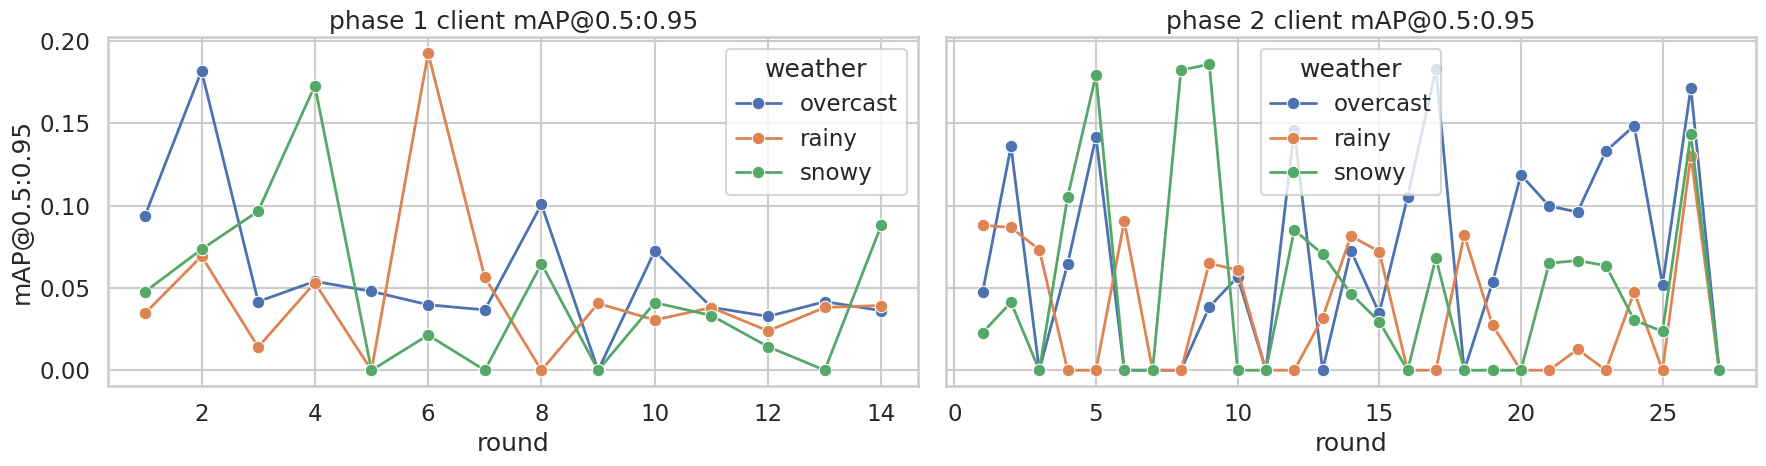

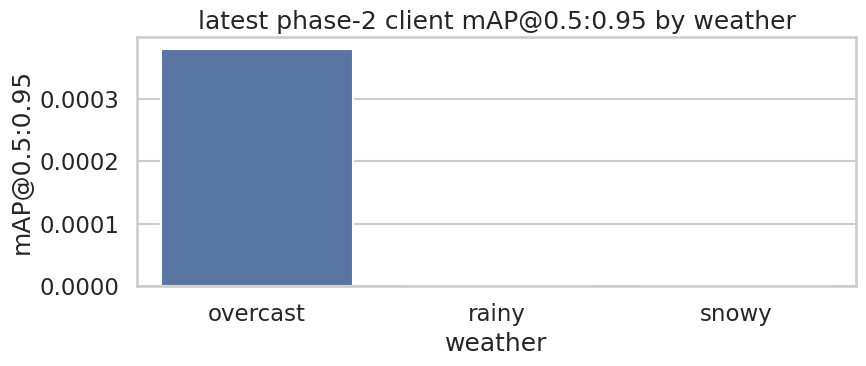

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, phase in zip(axes, [1, 2]):
    phase_df = client_summary[client_summary["phase"] == phase].copy()
    if phase_df.empty:
        ax.set_visible(False)
        continue
    plot_line(
        ax,
        phase_df,
        x="round",
        y="final_metrics/mAP_0.5:0.95",
        hue="weather",
        marker="o",
    )
    ax.set_title(f"phase {phase} client mAP@0.5:0.95")
    ax.set_xlabel("round")
    ax.set_ylabel("mAP@0.5:0.95")

plt.tight_layout()
plt.show()

latest_phase2_clients = (
    client_summary[client_summary["phase"] == 2]
    .sort_values(["weather", "round"])
    .groupby("weather", as_index=False)
    .tail(1)
    .sort_values("weather")
)
if not latest_phase2_clients.empty:
    plt.figure(figsize=(9, 4))
    plot_bar(
        plt.gca(),
        latest_phase2_clients,
        x="weather",
        y="final_metrics/mAP_0.5:0.95",
    )
    plt.title("latest phase-2 client mAP@0.5:0.95 by weather")
    plt.xlabel("weather")
    plt.ylabel("mAP@0.5:0.95")
    plt.tight_layout()
    plt.show()

## 8. DQA vs FedSTO Snapshot

If the FedSTO baseline summary is present, compare the same headline checkpoints side by side so the server story is easy to read without opening two notebooks.

,method,checkpoint,run_name,phase,round,metric_source,precision,recall,map50,map50_95
0,DQA-CWA v2,warmup,runtime_server_warmup,0,0,best,0.5826,0.4060,0.4233,0.2323
1,DQA-CWA v2,best_phase1_server,dqa_phase1_round002_server,1,2,best,0.5770,0.4349,0.4329,0.2446
2,DQA-CWA v2,best_phase2_server,dqa_phase2_round012_server,2,12,best,0.6960,0.3553,0.3984,0.2149
3,DQA-CWA v2,final_phase2_server,dqa_phase2_round027_server,2,27,final,0.6821,0.3507,0.3791,0.2092
4,FedSTO,warmup,runtime_server_warmup,0,0,best,0.6806,0.4449,0.4807,0.2790
5,FedSTO,best_phase1_server,phase1_round002_server,1,2,best,0.7499,0.4268,0.4831,0.2746
6,FedSTO,best_phase2_server,phase2_round058_server,2,58,best,0.7128,0.3805,0.4202,0.2344
7,FedSTO,final_phase2_server,phase2_round150_server,2,150,final,0.6832,0.3676,0.3907,0.2158


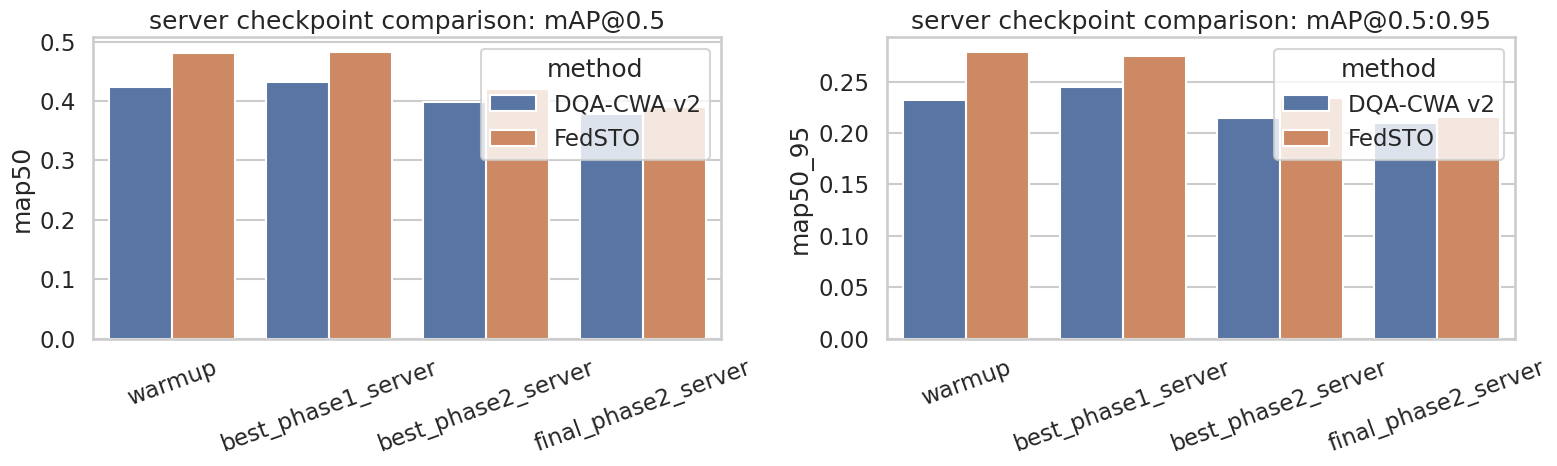

In [10]:
def comparable_checkpoint_rows(summary: pd.DataFrame, method: str) -> pd.DataFrame:
    rows = []

    def append_frame(label: str, frame: pd.DataFrame, source: str) -> None:
        if frame.empty:
            return
        chosen = frame.iloc[0]
        prefix = "best" if source == "best" else "final"
        rows.append(
            {
                "method": method,
                "checkpoint": label,
                "run_name": chosen["run_name"],
                "phase": chosen["phase"],
                "round": chosen["round"],
                "metric_source": source,
                "precision": chosen[f"{prefix}_metrics/precision"],
                "recall": chosen[f"{prefix}_metrics/recall"],
                "map50": chosen[f"{prefix}_metrics/mAP_0.5"],
                "map50_95": chosen[f"{prefix}_metrics/mAP_0.5:0.95"],
            }
        )

    append_frame("warmup", summary[summary["phase"] == 0].sort_values("best_metrics/mAP_0.5:0.95", ascending=False).head(1), "best")
    append_frame("best_phase1_server", summary[(summary["phase"] == 1) & (summary["role"] == "server")].sort_values("best_metrics/mAP_0.5:0.95", ascending=False).head(1), "best")
    append_frame("best_phase2_server", summary[(summary["phase"] == 2) & (summary["role"] == "server")].sort_values("best_metrics/mAP_0.5:0.95", ascending=False).head(1), "best")
    append_frame("final_phase2_server", summary[(summary["phase"] == 2) & (summary["role"] == "server")].sort_values("round").tail(1), "final")

    return pd.DataFrame(rows)


comparison_frames = [comparable_checkpoint_rows(run_summary, METHOD_LABEL)]
if FEDSTO_TRAINING_SUMMARY.exists():
    fedsto_summary = pd.read_csv(FEDSTO_TRAINING_SUMMARY)
    comparison_frames.append(comparable_checkpoint_rows(fedsto_summary, "FedSTO"))
else:
    fedsto_summary = pd.DataFrame()
    print("FedSTO training summary not found:", FEDSTO_TRAINING_SUMMARY)

checkpoint_comparison = pd.concat(comparison_frames, ignore_index=True)
display(checkpoint_comparison.round(4))

if checkpoint_comparison["method"].nunique() > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_bar(axes[0], checkpoint_comparison, x="checkpoint", y="map50", hue="method")
    plot_bar(axes[1], checkpoint_comparison, x="checkpoint", y="map50_95", hue="method")
    axes[0].set_title("server checkpoint comparison: mAP@0.5")
    axes[1].set_title("server checkpoint comparison: mAP@0.5:0.95")
    for ax in axes:
        ax.tick_params(axis="x", rotation=20)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

## 9. FedSTO vs DQA Round Curves

The checkpoint snapshot is useful, but the curves matter more for the "should we just add rounds?" question. This section overlays both methods round by round when the FedSTO training summary is available.

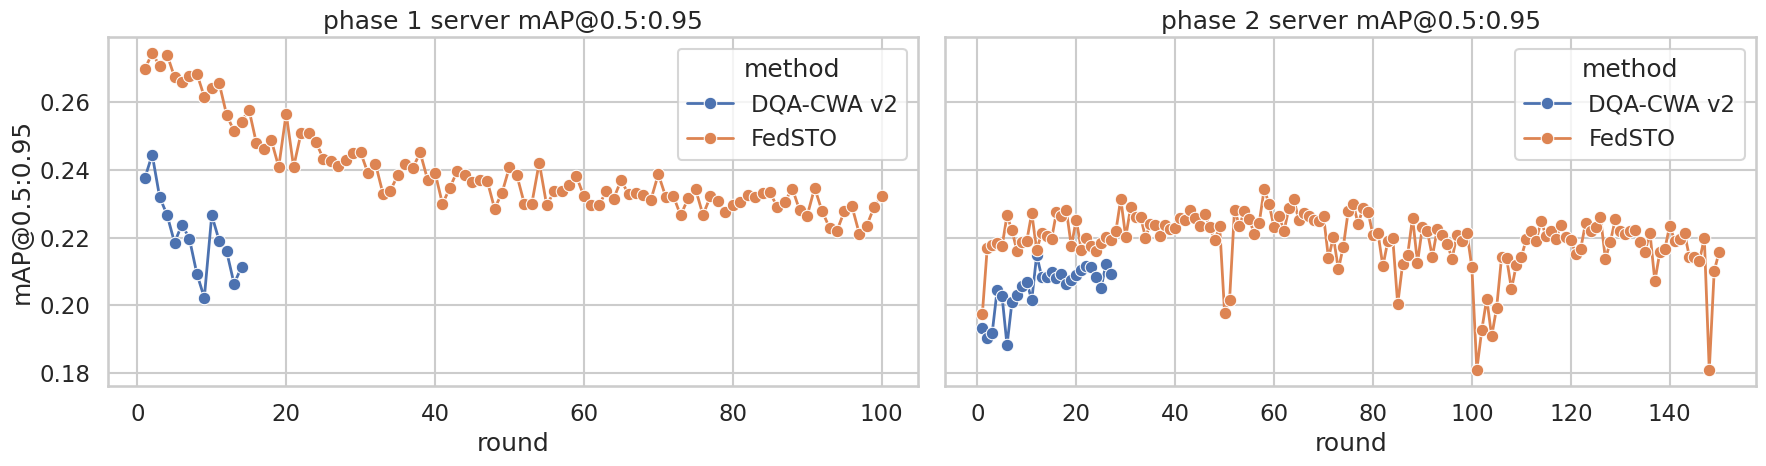

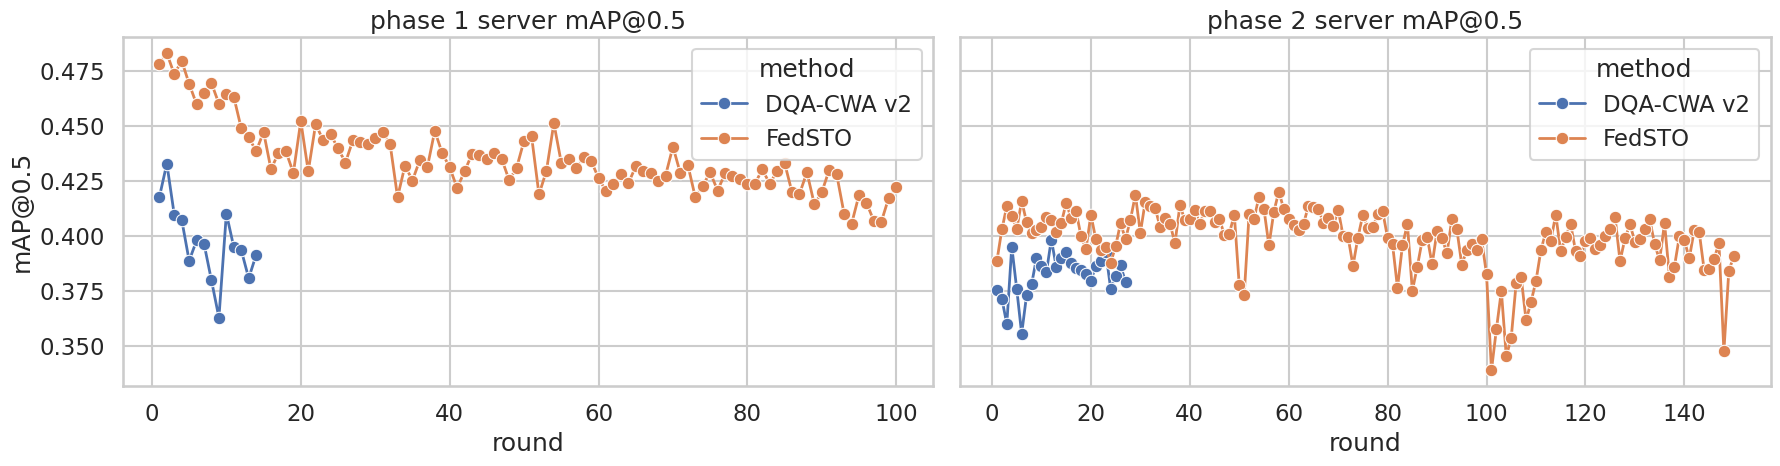

In [11]:
if FEDSTO_TRAINING_SUMMARY.exists():
    fedsto_summary = pd.read_csv(FEDSTO_TRAINING_SUMMARY)
    fedsto_server = fedsto_summary[fedsto_summary["role"].isin(["warmup", "server"])].copy()

    compare_rows = []
    for method, frame in [(METHOD_LABEL, server_summary.copy()), ("FedSTO", fedsto_server.copy())]:
        method_df = frame[frame["role"] == "server"].copy()
        if method_df.empty:
            continue
        for phase in [1, 2]:
            phase_df = method_df[method_df["phase"] == phase].sort_values("round").copy()
            if phase_df.empty:
                continue
            phase_df["method"] = method
            compare_rows.append(phase_df)

    if compare_rows:
        compare_df = pd.concat(compare_rows, ignore_index=True)
        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
        for ax, phase in zip(axes, [1, 2]):
            phase_df = compare_df[compare_df["phase"] == phase].copy()
            plot_line(
                ax,
                phase_df,
                x="round",
                y="final_metrics/mAP_0.5:0.95",
                hue="method",
                marker="o",
            )
            ax.set_title(f"phase {phase} server mAP@0.5:0.95")
            ax.set_xlabel("round")
            ax.set_ylabel("mAP@0.5:0.95")
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
        for ax, phase in zip(axes, [1, 2]):
            phase_df = compare_df[compare_df["phase"] == phase].copy()
            plot_line(
                ax,
                phase_df,
                x="round",
                y="final_metrics/mAP_0.5",
                hue="method",
                marker="o",
            )
            ax.set_title(f"phase {phase} server mAP@0.5")
            ax.set_xlabel("round")
            ax.set_ylabel("mAP@0.5")
        plt.tight_layout()
        plt.show()
else:
    print("FedSTO training summary not found:", FEDSTO_TRAINING_SUMMARY)

## 10. Paper-Eval Status and Visual Artifacts

Use the complete paper-eval summary if it exists. If not, fall back to partial DQA evaluation artifacts so we can still see what has already been produced.

,method,checkpoint_label,checkpoint_path,split,split_list,status,returncode,images,labels,precision,recall,map50,map50_95,log_file,command,error
0,FedSTO,warmup,/app/Object_Detection/navigating_data_heteroge...,cloudy,/app/Object_Detection/navigating_data_heteroge...,ok,0,738.0,14937.0,0.784,0.4190,0.495,0.2790,/app/Object_Detection/navigating_data_heteroge...,/root/micromamba/envs/al_yolov8/bin/python val...,NaN
1,FedSTO,final,/app/Object_Detection/navigating_data_heteroge...,cloudy,/app/Object_Detection/navigating_data_heteroge...,ok,0,738.0,14937.0,0.162,0.0431,0.105,0.0639,/app/Object_Detection/navigating_data_heteroge...,/root/micromamba/envs/al_yolov8/bin/python val...,NaN


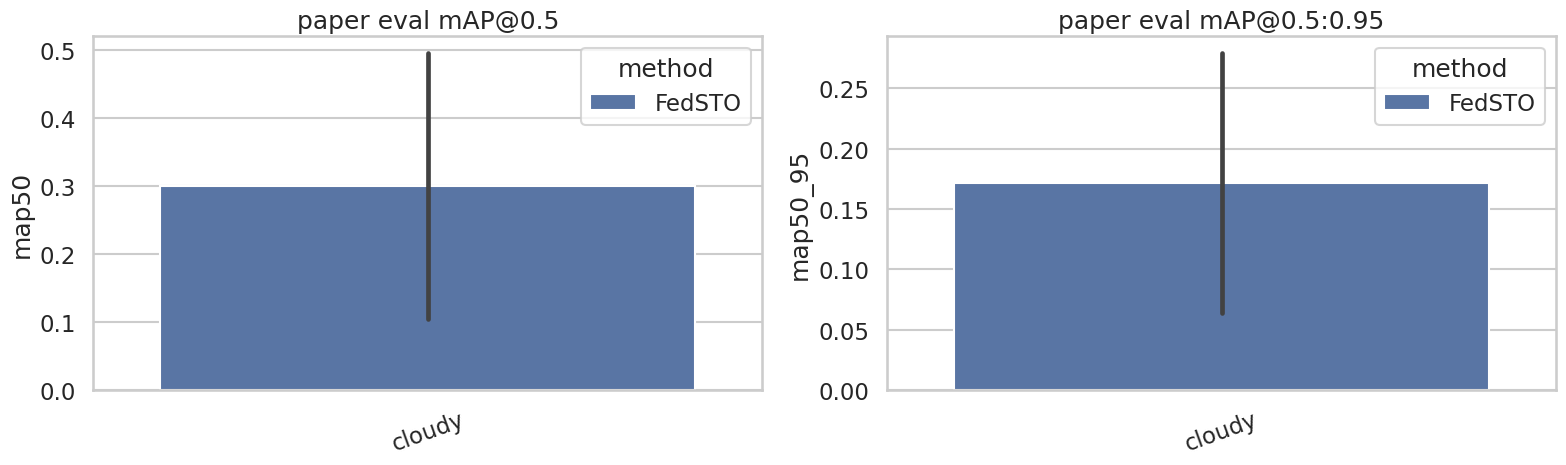

In [12]:
paper_eval_frames = []
dqa_paper_eval_summary = VALIDATION_ROOT / "paper_protocol_eval_summary.csv"
if dqa_paper_eval_summary.exists():
    dqa_eval_df = pd.read_csv(dqa_paper_eval_summary)
    dqa_eval_df.insert(0, "method", METHOD_LABEL)
    paper_eval_frames.append(dqa_eval_df)

if FEDSTO_PAPER_EVAL_SUMMARY.exists():
    fedsto_eval_df = pd.read_csv(FEDSTO_PAPER_EVAL_SUMMARY)
    fedsto_eval_df.insert(0, "method", "FedSTO")
    paper_eval_frames.append(fedsto_eval_df)

if paper_eval_frames:
    paper_eval_comparison = pd.concat(paper_eval_frames, ignore_index=True)
    display(paper_eval_comparison.round(4))

    ok_rows = paper_eval_comparison[paper_eval_comparison["status"] == "ok"].copy()
    if not ok_rows.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        plot_bar(axes[0], ok_rows, x="split", y="map50", hue="method")
        plot_bar(axes[1], ok_rows, x="split", y="map50_95", hue="method")
        axes[0].set_title("paper eval mAP@0.5")
        axes[1].set_title("paper eval mAP@0.5:0.95")
        for ax in axes:
            ax.tick_params(axis="x", rotation=20)
            ax.set_xlabel("")
        plt.tight_layout()
        plt.show()
else:
    print("No complete paper-protocol summary CSV is available yet.")

partial_log_dir = VALIDATION_ROOT / "paper_protocol_logs"
partial_run_dir = VALIDATION_ROOT / "paper_protocol_val_runs"

partial_log_rows = [
    {
        "log_file": path.name,
        "bytes": path.stat().st_size,
        "modified_utc": modified_utc(path),
    }
    for path in sorted(partial_log_dir.glob("*.log"))
]
if partial_log_rows:
    display(pd.DataFrame(partial_log_rows))

partial_run_rows = [
    {
        "run_dir": path.name,
        "has_pr_curve": (path / "PR_curve.png").exists(),
        "has_confusion_matrix": (path / "confusion_matrix.png").exists(),
        "has_p_curve": (path / "P_curve.png").exists(),
        "has_r_curve": (path / "R_curve.png").exists(),
        "modified_utc": modified_utc(path),
    }
    for path in sorted(partial_run_dir.glob("*"))
    if path.is_dir()
]
if partial_run_rows:
    display(pd.DataFrame(partial_run_rows))

preview_dir = next(
    (
        path
        for path in sorted(partial_run_dir.glob("*"))
        if path.is_dir() and (path / "PR_curve.png").exists() and (path / "confusion_matrix.png").exists()
    ),
    None,
)
if preview_dir is not None:
    print("Previewing DQA partial paper-eval artifacts from:", preview_dir.name)
    display(NotebookImage(filename=str(preview_dir / "PR_curve.png"), width=700))
    display(NotebookImage(filename=str(preview_dir / "confusion_matrix.png"), width=700))

## 11. Artifact Index

A last table with the main files we usually click next.

In [13]:
def artifact_row(path: Path, label: str) -> dict:
    exists = path.exists()
    return {
        "label": label,
        "path": str(path),
        "exists": exists,
        "modified_utc": modified_utc(path),
    }


artifact_rows = [
    artifact_row(DQA_ROOT / "README.md", "readme"),
    artifact_row(NOTEBOOK_GENERATOR, "notebook_generator"),
    artifact_row(WORK_ROOT / "manifest.json", "manifest"),
    artifact_row(WORK_ROOT / "history.json", "history"),
    artifact_row(VALIDATION_ROOT / "tables" / "training_run_summary.csv", "training_run_summary_csv"),
    artifact_row(VALIDATION_ROOT / "paper_protocol_eval_summary.csv", "paper_eval_summary_csv"),
    artifact_row(VALIDATION_ROOT / "paper_protocol_eval_manifest.json", "paper_eval_manifest_json"),
    artifact_row(VALIDATION_ROOT / "paper_protocol_val_runs", "paper_eval_run_dir"),
    artifact_row(WORK_ROOT / "global_checkpoints", "global_checkpoints_dir"),
    artifact_row(STATS_ROOT, "stats_dir"),
]
display(pd.DataFrame(artifact_rows))

,label,path,exists,modified_utc
0,readme,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T03:58:21.418132+00:00
1,notebook_generator,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T10:33:47.056110+00:00
2,manifest,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T11:14:36.192856+00:00
3,history,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:08:36.962626+00:00
4,training_run_summary_csv,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-28T00:53:02.326209+00:00
5,paper_eval_summary_csv,/app/Object_Detection/dynamic_quality_aware_cl...,False,
6,paper_eval_manifest_json,/app/Object_Detection/dynamic_quality_aware_cl...,False,
7,paper_eval_run_dir,/app/Object_Detection/dynamic_quality_aware_cl...,False,
8,global_checkpoints_dir,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:08:36.972626+00:00
9,stats_dir,/app/Object_Detection/dynamic_quality_aware_cl...,True,2026-04-27T20:05:53.239378+00:00
